Чтобы результаты экспериментов воспроизводились, зафиксируем seed's:

In [59]:
#import torch
import random
import numpy as np

def set_random_seed(seed):
    #torch.manual_seed(seed)
    #torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    #torch.backends.cudnn.deterministic = True
set_random_seed(42)

Прогнозирование многомерного временного ряда.

Установка и импорт необходимых библиотек:

In [58]:
#import math
#import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
#from torch.utils.data import Dataset, DataLoader
#from sklearn.linear_model import LinearRegression
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## Загрузка и изучение данных

In [20]:
dataset = pd.read_csv('one_probe_ts.csv')

In [21]:
dataset.head(5)

,Unnamed: 0,lts,endtime,dst_name,ttr,dst_addr,src_addr,paris_id,result,msm_id,prb_id,timestamp,from,stored_timestamp,hop_1_rtt_mean,ASN,system,timezone,msk_time
0,74,1,1707338316,gov.ru,40.570804,95.173.128.89,10.237.140.138,1,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,10059,1707338244,213.242.63.247,1707338423,0.433000,12389,system: V3,3.0,2024-02-07 23:40:23
1,563,74,1707340111,gov.ru,28.158206,95.173.128.90,10.237.140.138,2,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,10059,1707340039,213.242.63.247,1707340210,0.467333,12389,system: V3,3.0,2024-02-08 00:10:10
2,1050,82,1707341916,gov.ru,38.968481,95.173.128.90,10.237.140.138,3,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,10059,1707341843,213.242.63.247,1707342026,0.425333,12389,system: V3,3.0,2024-02-08 00:40:26
3,1540,79,1707343718,gov.ru,28.034344,95.173.128.90,10.237.140.138,4,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,10059,1707343645,213.242.63.247,1707343836,0.438000,12389,system: V3,3.0,2024-02-08 01:10:36
4,2030,70,1707345513,gov.ru,40.271452,95.173.128.90,10.237.140.138,5,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,10059,1707345440,213.242.63.247,1707345659,0.452333,12389,system: V3,3.0,2024-02-08 01:40:59


In [22]:
dataset.result[0]

"[{'hop': 1, 'result': [{'from': '10.237.140.137', 'ttl': 64, 'size': 76, 'rtt': 0.478}, {'from': '10.237.140.137', 'ttl': 64, 'size': 76, 'rtt': 0.397}, {'from': '10.237.140.137', 'ttl': 64, 'size': 76, 'rtt': 0.424}]}, {'hop': 2, 'result': [{'from': '213.242.48.1', 'ttl': 254, 'size': 28, 'rtt': 1.472}, {'from': '213.242.48.1', 'ttl': 254, 'size': 28, 'rtt': 1.378}, {'from': '213.242.48.1', 'ttl': 254, 'size': 28, 'rtt': 1.339}]}, {'hop': 3, 'result': [{'from': '217.107.123.120', 'ttl': 253, 'size': 28, 'rtt': 2.025}, {'from': '217.107.123.120', 'ttl': 253, 'size': 28, 'rtt': 1.79}, {'from': '217.107.123.120', 'ttl': 253, 'size': 28, 'rtt': 1.849}]}, {'hop': 4, 'result': [{'from': '188.128.126.253', 'ttl': 253, 'size': 28, 'rtt': 23.118}, {'from': '188.128.126.253', 'ttl': 253, 'size': 28, 'rtt': 27.694}, {'from': '188.128.126.253', 'ttl': 253, 'size': 28, 'rtt': 23.181}]}, {'hop': 5, 'result': [{'from': '188.128.72.2', 'ttl': 252, 'size': 28, 'rtt': 30.6}, {'from': '188.128.72.2', '

In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        96 non-null     int64  
 1   lts               96 non-null     int64  
 2   endtime           96 non-null     int64  
 3   dst_name          96 non-null     object 
 4   ttr               96 non-null     float64
 5   dst_addr          96 non-null     object 
 6   src_addr          96 non-null     object 
 7   paris_id          96 non-null     int64  
 8   result            96 non-null     object 
 9   msm_id            96 non-null     int64  
 10  prb_id            96 non-null     int64  
 11  timestamp         96 non-null     int64  
 12  from              96 non-null     object 
 13  stored_timestamp  96 non-null     int64  
 14  hop_1_rtt_mean    96 non-null     float64
 15  ASN               96 non-null     int64  
 16  system            96 non-null     object 
 17 

### Получение признаков из таймстампа

In [24]:
dataset.msk_time

0     2024-02-07 23:40:23
1     2024-02-08 00:10:10
2     2024-02-08 00:40:26
3     2024-02-08 01:10:36
4     2024-02-08 01:40:59
             ...         
91    2024-02-09 21:10:29
92    2024-02-09 21:40:13
93    2024-02-09 22:13:09
94    2024-02-09 22:40:52
95    2024-02-09 23:13:10
Name: msk_time, Length: 96, dtype: object

In [25]:
dataset.msk_time = pd.to_datetime(dataset.msk_time)

In [26]:
dataset.msk_time

0    2024-02-07 23:40:23
1    2024-02-08 00:10:10
2    2024-02-08 00:40:26
3    2024-02-08 01:10:36
4    2024-02-08 01:40:59
             ...        
91   2024-02-09 21:10:29
92   2024-02-09 21:40:13
93   2024-02-09 22:13:09
94   2024-02-09 22:40:52
95   2024-02-09 23:13:10
Name: msk_time, Length: 96, dtype: datetime64[ns]

In [27]:
dataset['hour'] = dataset.msk_time.dt.hour
dataset['day_of_week'] = dataset.msk_time.dt.day_of_week

In [28]:
dataset

,Unnamed: 0,lts,endtime,dst_name,ttr,dst_addr,src_addr,paris_id,result,msm_id,...,timestamp,from,stored_timestamp,hop_1_rtt_mean,ASN,system,timezone,msk_time,hour,day_of_week
0,74,1,1707338316,gov.ru,40.570804,95.173.128.89,10.237.140.138,1,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707338244,213.242.63.247,1707338423,0.433000,12389,system: V3,3.0,2024-02-07 23:40:23,23,2
1,563,74,1707340111,gov.ru,28.158206,95.173.128.90,10.237.140.138,2,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707340039,213.242.63.247,1707340210,0.467333,12389,system: V3,3.0,2024-02-08 00:10:10,0,3
2,1050,82,1707341916,gov.ru,38.968481,95.173.128.90,10.237.140.138,3,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707341843,213.242.63.247,1707342026,0.425333,12389,system: V3,3.0,2024-02-08 00:40:26,0,3
3,1540,79,1707343718,gov.ru,28.034344,95.173.128.90,10.237.140.138,4,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707343645,213.242.63.247,1707343836,0.438000,12389,system: V3,3.0,2024-02-08 01:10:36,1,3
4,2030,70,1707345513,gov.ru,40.271452,95.173.128.90,10.237.140.138,5,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707345440,213.242.63.247,1707345659,0.452333,12389,system: V3,3.0,2024-02-08 01:40:59,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,44731,27,1707502106,gov.ru,48.472854,95.173.128.89,10.237.140.138,12,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707502034,213.242.63.247,1707502229,0.417000,12389,system: V3,3.0,2024-02-09 21:10:29,21,4
92,45224,72,1707503915,gov.ru,24.472186,95.173.128.90,10.237.140.138,13,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707503842,213.242.63.247,1707504013,0.453333,12389,system: V3,3.0,2024-02-09 21:40:13,21,4
93,45716,31,1707505708,gov.ru,24.281689,95.173.128.89,10.237.140.138,14,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707505636,213.242.63.247,1707505989,0.427000,12389,system: V3,3.0,2024-02-09 22:13:09,22,4
94,46208,68,1707507513,gov.ru,24.405149,95.173.128.90,10.237.140.138,15,"[{'hop': 1, 'result': [{'from': '10.237.140.13...",67531313,...,1707507441,213.242.63.247,1707507652,0.404000,12389,system: V3,3.0,2024-02-09 22:40:52,22,4


## Формирование датасета

In [110]:
'''
digits = dataset.drop(columns=['dst_name','dst_name','src_addr','result','from','system', 'msk_time','stored_timestamp', 'timestamp','endtime', 'msm_id'])
digits = digits.drop(columns=['Unnamed: 0'])
digits = digits.drop(columns=['ASN'])
digits = digits.drop(columns=['prb_id', 'timezone'])
digits = digits.drop(columns=['paris_id'])
digits = digits.drop(columns=['dst_addr'])
'''

digits = dataset[['hop_1_rtt_mean', 'hour', 'day_of_week']]

Визуализируем целевую переменную.

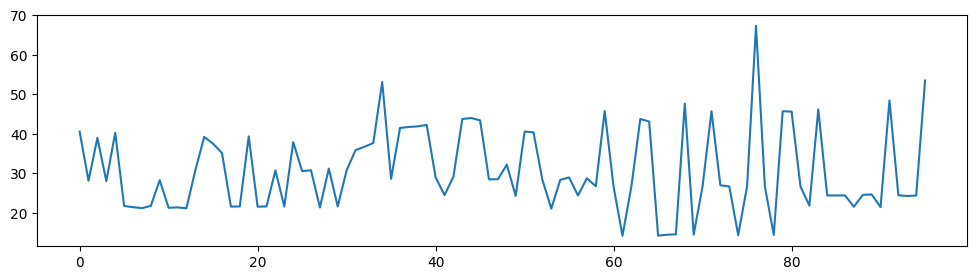

In [111]:
plt.rcParams["figure.figsize"] = (12, 3)

plt.plot(dataset["ttr"])
#plt.xlabel("Time")
#plt.ylabel("Price (USD)")
#plt.title("Bitcoin price over time")
plt.show()

Также давайте посмотрим, какие тут признаки

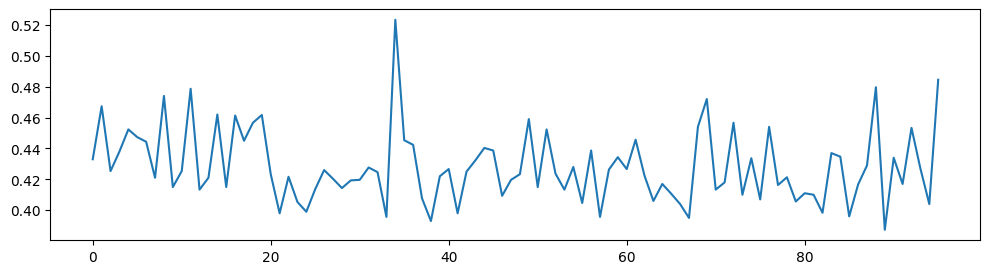

In [112]:
digits['hop_1_rtt_mean'].plot()
plt.show()

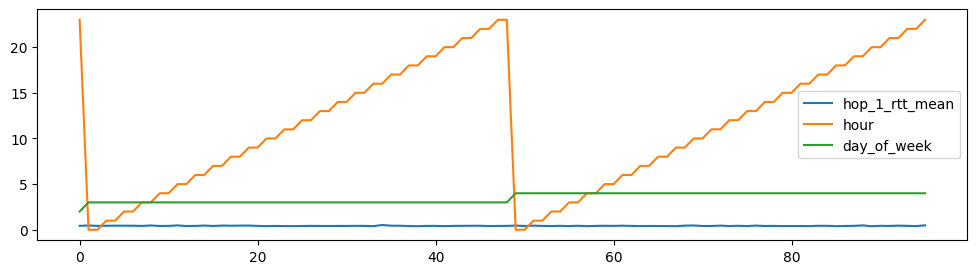

In [113]:
digits.plot()
plt.show()

In [114]:
digits

,hop_1_rtt_mean,hour,day_of_week
0,0.433000,23,2
1,0.467333,0,3
2,0.425333,0,3
3,0.438000,1,3
4,0.452333,1,3
...,...,...,...
91,0.417000,21,4
92,0.453333,21,4
93,0.427000,22,4
94,0.404000,22,4


In [115]:
#pip install pmdarima

Раздели данные на train-val-test

In [116]:


train_data = digits[:70]
val_data = digits[70:80]
test_data = digits[80:]

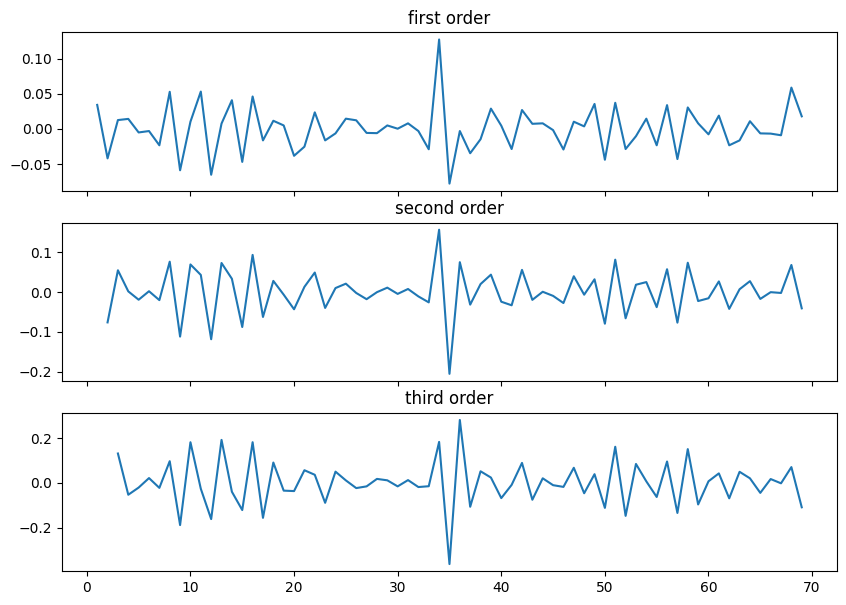

Test statistic   -7.523941e+00
p-value           3.727444e-11
used_lag          0.000000e+00
NOBS              6.900000e+01
dtype: float64
Test statistic    -4.944180
p-value            0.000029
used_lag           7.000000
NOBS              61.000000
dtype: float64
Test statistic    -5.629157
p-value            0.000001
used_lag           8.000000
NOBS              59.000000
dtype: float64
Test statistic   -5.902917e+00
p-value           2.751034e-07
used_lag          1.100000e+01
NOBS              5.500000e+01
dtype: float64


In [117]:
import statsmodels.api as sm
# first-order difference
dfOrigin = train_data['hop_1_rtt_mean']
df1 = dfOrigin.diff(1).dropna()
# second-order difference
df2 = df1.diff(1).dropna()
# third-order difference
df3 = df2.diff(1).dropna()

# plot three curves and check the stationary
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(10, 7))

ax1.plot(df1)
ax1.set_title("first order")

ax2.plot(df2)
ax2.set_title("second order")

ax3.plot(df3)
ax3.set_title("third order")

plt.show()


def check_stationary(ts_data):
    df_test = sm.tsa.adfuller(ts_data)
    output = pd.Series(
        df_test[0:4], index=["Test statistic", "p-value", "used_lag", "NOBS"]
    )
    print(output)

check_stationary(dfOrigin)
check_stationary(df1)
check_stationary(df2)
check_stationary(df3)

c:\Users\Пауль\Desktop\Работка с трафиком RIPE\.venv\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


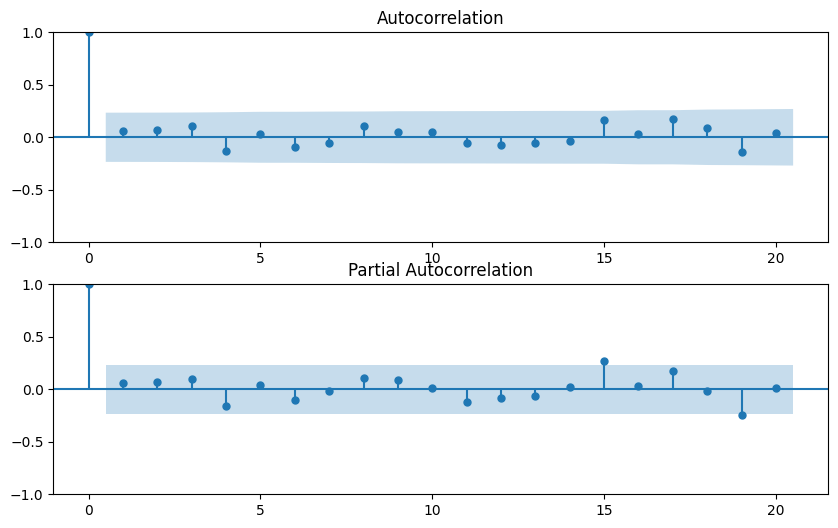

In [118]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(train_data['hop_1_rtt_mean'].values.squeeze(), lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(train_data['hop_1_rtt_mean'], lags=20, ax=ax2)
plt.show()

## SARIMA

Начнём с того, что попробуем по целевому показателю предсказать самого себя, то есть, как и раньше, работаем с одномерным временным рядом.

In [119]:
train_data = train_data['hop_1_rtt_mean']
val_data = val_data['hop_1_rtt_mean']
test_data = test_data['hop_1_rtt_mean']

Стартовые параметры взяты по умолчанию.

In [120]:
stepwise_model = auto_arima(
    train_data,
    start_p=1,
    start_q=1,
    max_p=3,
    max_q=3,
    m=5,
    start_P=0,
    seasonal=True,
    d=1,
    D=1,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    maxiter=50, #default 50
)
print(stepwise_model.aic())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[5]             : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=-222.187, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=-246.470, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=-280.022, Time=0.09 sec
 ARIMA(0,1,1)(0,1,0)[5]             : AIC=inf, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[5]             : AIC=-278.417, Time=0.19 sec
 ARIMA(0,1,1)(0,1,2)[5]             : AIC=-278.639, Time=0.32 sec
 ARIMA(0,1,1)(1,1,0)[5]             : AIC=-262.386, Time=0.11 sec
 ARIMA(0,1,1)(1,1,2)[5]             : AIC=inf, Time=0.31 sec
 ARIMA(0,1,0)(0,1,1)[5]             : AIC=inf, Time=0.08 sec
 ARIMA(0,1,2)(0,1,1)[5]             : AIC=inf, Time=0.20 sec
 ARIMA(1,1,0)(0,1,1)[5]             : AIC=inf, Time=0.12 sec
 ARIMA(1,1,2)(0,1,1)[5]             : AIC=inf, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[5] intercept   : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,1,1)(0,1,1)[5]          
Total fit time: 1.975 seco

In [121]:
print(stepwise_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   70
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 5)   Log Likelihood                 143.011
Date:                           Tue, 04 Jun 2024   AIC                           -280.022
Time:                                   23:24:02   BIC                           -273.545
Sample:                                        0   HQIC                          -277.470
                                            - 70                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9581      0.201     -4.763      0.000      -1.352      -0.564
ma.S.L5       -0.9384      0.453     -2.072

In [122]:
start_data = train_data.index[-1]

future_forecast = stepwise_model.predict(start=start_data, n_periods=len(val_data)+len(test_data))

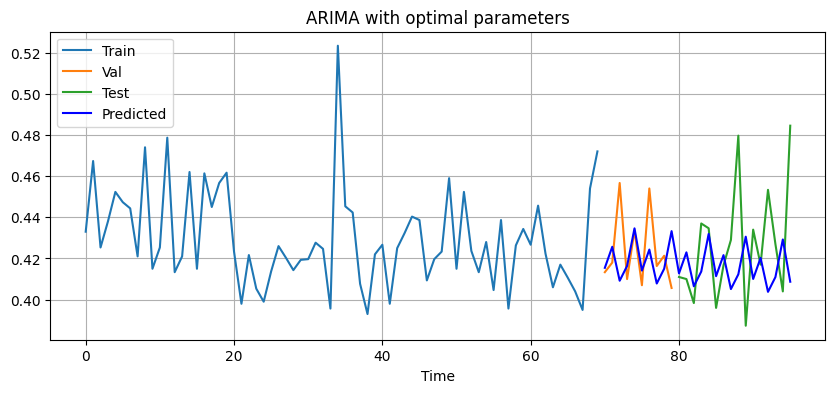

In [123]:
plt.figure(figsize=(10, 4))
plt.plot(train_data, label="Train")
plt.plot(val_data, label="Val")
plt.plot(test_data, label="Test")
plt.plot(future_forecast, color="blue", label="Predicted")

plt.title("ARIMA with optimal parameters")
plt.xlabel("Time")
#plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
rmse = np.sqrt(mean_squared_error(val_data, future_forecast[:len(val_data)]))
print("RMSE: " + str(rmse))

RMSE: 0.02040829820247848


In [125]:
mape = np.sqrt(mean_absolute_percentage_error(val_data, future_forecast[:len(val_data)]))
print("MAPE: " + str(mape * 100), ' %')

MAPE: 18.20711271204342  %


In [126]:
stepwise_model = auto_arima(
    train_data,
    start_p=1,
    start_q=1,
    max_p=3,
    max_q=3,
    m=10,
    start_P=0,
    seasonal=True,
    d=1,
    D=1,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    maxiter=50, #default 50
)
print(stepwise_model.aic())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[10]             : AIC=inf, Time=0.40 sec
 ARIMA(0,1,0)(0,1,0)[10]             : AIC=-196.391, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[10]             : AIC=-233.364, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[10]             : AIC=-249.706, Time=0.16 sec
 ARIMA(0,1,1)(0,1,0)[10]             : AIC=-228.530, Time=0.05 sec
 ARIMA(0,1,1)(1,1,1)[10]             : AIC=inf, Time=0.39 sec
 ARIMA(0,1,1)(0,1,2)[10]             : AIC=inf, Time=0.58 sec
 ARIMA(0,1,1)(1,1,0)[10]             : AIC=-245.007, Time=0.18 sec
 ARIMA(0,1,1)(1,1,2)[10]             : AIC=inf, Time=0.55 sec
 ARIMA(0,1,0)(0,1,1)[10]             : AIC=-223.874, Time=0.03 sec
 ARIMA(0,1,2)(0,1,1)[10]             : AIC=-248.256, Time=0.20 sec
 ARIMA(1,1,0)(0,1,1)[10]             : AIC=inf, Time=0.24 sec
 ARIMA(1,1,2)(0,1,1)[10]             : AIC=inf, Time=0.33 sec
 ARIMA(0,1,1)(0,1,1)[10] intercept   : AIC=inf, Time=0.42 sec

Best model:  ARIMA(0,1,1)(0,1,1)[10]          
Total 

In [127]:
start_data = train_data.index[-1]

future_forecast = stepwise_model.predict(start=start_data, n_periods=len(val_data)+len(test_data))

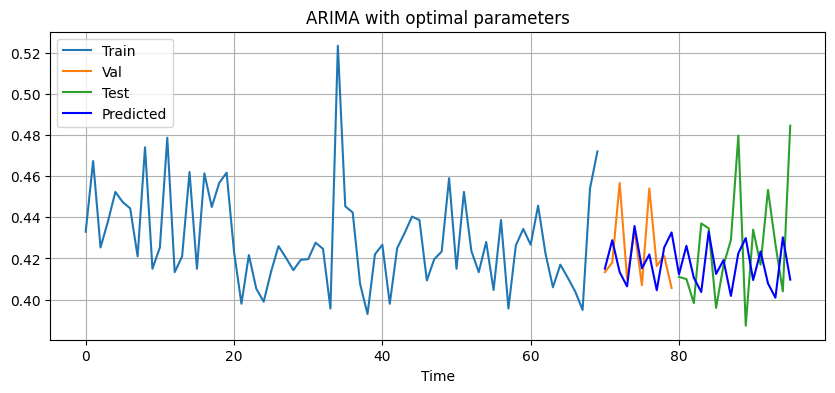

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_data, label="Train")
plt.plot(val_data, label="Val")
plt.plot(test_data, label="Test")
plt.plot(future_forecast, color="blue", label="Predicted")

plt.title("ARIMA with optimal parameters")
plt.xlabel("Time")
#plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [129]:
rmse = np.sqrt(mean_squared_error(val_data, future_forecast[:len(val_data)]))
print("RMSE: " + str(rmse))

mape = np.sqrt(mean_absolute_percentage_error(val_data, future_forecast[:len(val_data)]))
print("MAPE: " + str(mape * 100), ' %')

RMSE: 0.019980123664257925
MAPE: 18.25972300637531  %


Получилось не то, чтобы очень качественно.

## SARIMAX

Попробуем воспользоваться поставшимися признаками, чтобы уточнить предсказание.

Теперь мы подаём не только `Y`, но и `X`, то есть решаем регрессионную задачу.

In [130]:
train_data = digits[:70]
val_data = digits[70:80]
test_data = digits[80:]

In [137]:
stepwise_model = auto_arima(
    y = train_data['hop_1_rtt_mean'].values,
    X = train_data.drop(columns=['hop_1_rtt_mean']),
    start_p=1,
    start_q=1,
    max_p=13,
    max_q=13,
    max_d=13,
    m=10,
    start_P=0,
    start_Q=0,
    seasonal=True,
    d=None,
    D=None,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    maxiter=150, #default 50
)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[10] intercept   : AIC=-301.241, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[10] intercept   : AIC=-323.435, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[10] intercept   : AIC=-319.430, Time=0.51 sec
 ARIMA(0,0,1)(0,0,1)[10] intercept   : AIC=-319.181, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[10]             : AIC=-192.416, Time=0.02 sec
 ARIMA(0,0,0)(1,0,0)[10] intercept   : AIC=-321.434, Time=0.25 sec
 ARIMA(0,0,0)(0,0,1)[10] intercept   : AIC=-321.437, Time=0.17 sec
 ARIMA(0,0,0)(1,0,1)[10] intercept   : AIC=-297.097, Time=0.19 sec
 ARIMA(1,0,0)(0,0,0)[10] intercept   : AIC=-321.433, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[10] intercept   : AIC=-321.436, Time=0.11 sec

Best model:  ARIMA(0,0,0)(0,0,0)[10] intercept
Total fit time: 1.875 seconds


In [138]:
train_data['hop_1_rtt_mean']

0     0.433000
1     0.467333
2     0.425333
3     0.438000
4     0.452333
        ...   
65    0.410667
66    0.404000
67    0.395000
68    0.454000
69    0.472000
Name: hop_1_rtt_mean, Length: 70, dtype: float64

In [139]:
print(stepwise_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   70
Model:                        SARIMAX   Log Likelihood                 165.718
Date:                Tue, 04 Jun 2024   AIC                           -323.435
Time:                        23:24:58   BIC                           -314.441
Sample:                             0   HQIC                          -319.863
                                 - 70                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.4783      0.025     19.006      0.000       0.429       0.528
hour           -0.0010      0.001     -1.793      0.073      -0.002    9.29e-05
day_of_week    -0.0120      0.007     -1.750    

Для предсказания в функцию `predict` теперь нужно подать признаки.

In [140]:
start_data = train_data.index[-1]
future_forecast_val = stepwise_model.predict(X = val_data.drop(columns=['hop_1_rtt_mean']), start=start_data, n_periods=len(val_data))

start_data = val_data.index[-1]
future_forecast_test = stepwise_model.predict(X = test_data.drop(columns=['hop_1_rtt_mean']), start=start_data, n_periods=len(test_data))

Здесь есть особенность в том, что начальные индексы по времени `future_forecast_val` и `future_forecast_test` совпадут. Поэтому для визуализации мы сдвинем на размер валидации, т.е. на 153 дня.

In [141]:
future_forecast_test.index += 10

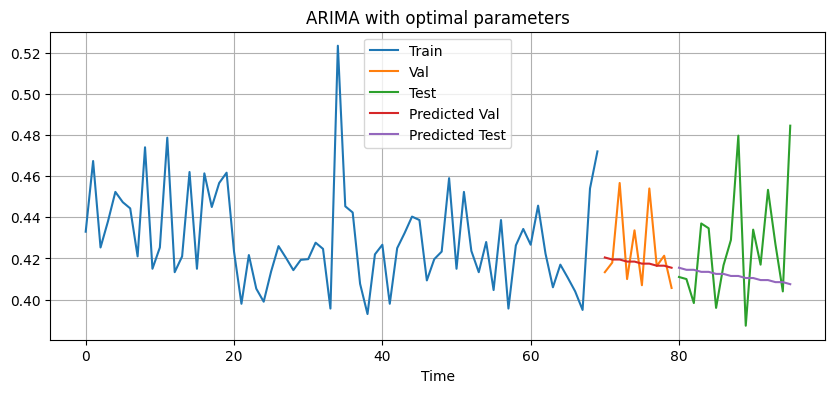

In [142]:
plt.figure(figsize=(10, 4))
plt.plot(train_data["hop_1_rtt_mean"], label="Train")
plt.plot(val_data["hop_1_rtt_mean"], label="Val")
plt.plot(test_data["hop_1_rtt_mean"], label="Test")
plt.plot(future_forecast_val,  label="Predicted Val")
plt.plot(future_forecast_test, label="Predicted Test")

plt.title("ARIMA with optimal parameters")
plt.xlabel("Time")
#plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

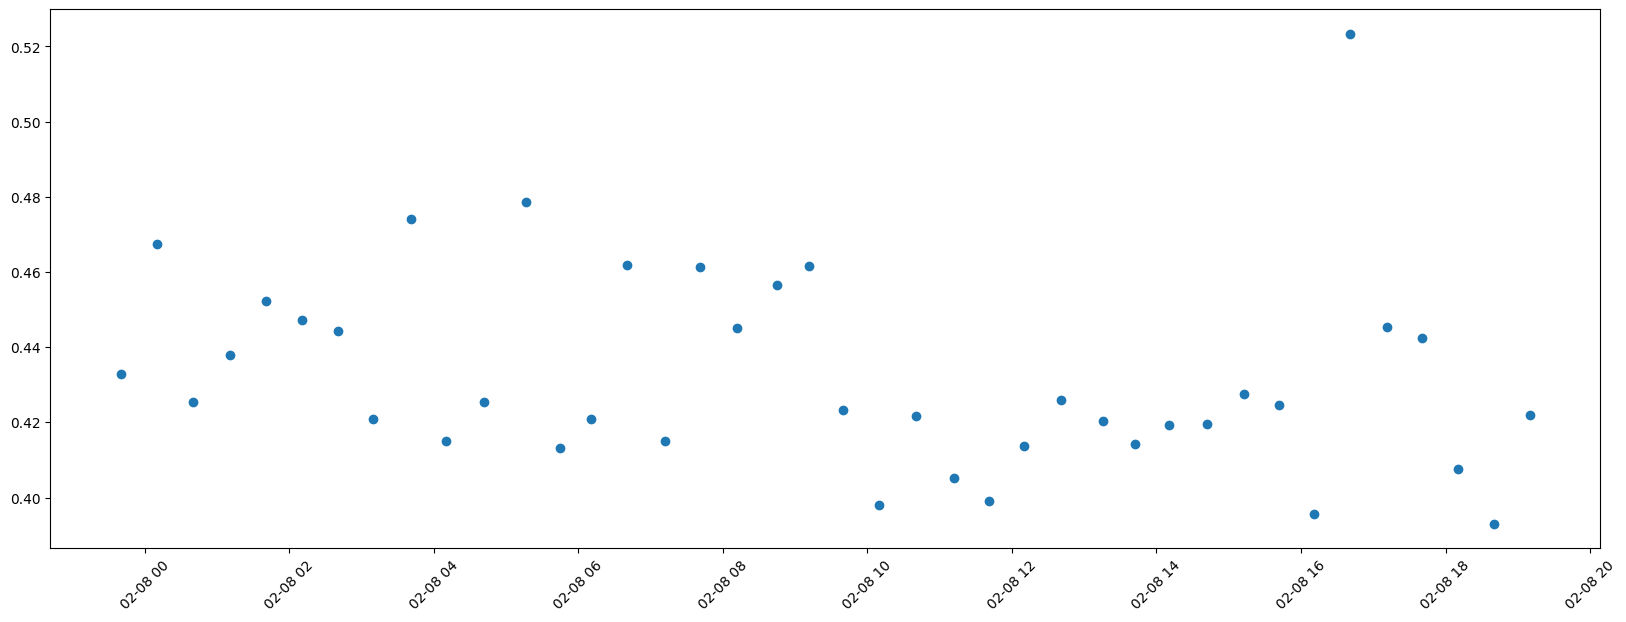

In [154]:
#dataset.msk_time
#plt.plot(dataset.hop_1_rtt_mean)
plt.figure(figsize=(20, 7))
plt.plot_date(dataset[:40].msk_time, dataset[:40].hop_1_rtt_mean)
plt.xticks(rotation=45)
plt.show()

In [143]:
rmse = np.sqrt(mean_squared_error(val_data["hop_1_rtt_mean"], future_forecast_val))
print("RMSE: " + str(rmse))

mape = np.sqrt(mean_absolute_percentage_error(val_data['hop_1_rtt_mean'], future_forecast_val))
print("MAPE: " + str(mape * 100), ' %')

RMSE: 0.018169044693332942
MAPE: 17.328287796097054  %


Фишка SARIMAX в том, что мы можем придумывать дополнительные признаки и подавать их в ту же модель, просто добавляя столбцы в таблице в `pandas`.